In [1]:
!pip install pandas matplotlib seaborn plotly textblob nltk wordcloud joblib scikit-learn

In [2]:
# Import necessary libraries
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For plotting
import matplotlib.patches as mpatch
import seaborn as sns  # For statistical data visualization
from textblob import TextBlob  # For sentiment analysis
from wordcloud import WordCloud  # For generating word clouds
import nltk  # Natural Language Toolkit for text processing
import re  # For regular expressions
import joblib  # For saving objects
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.ensemble import RandomForestClassifier  # For classification
from sklearn.linear_model import LogisticRegression  # Alternative classifier
from sklearn.metrics import accuracy_score, classification_report  # For evaluation

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [3]:
# Load the dataset into a DataFrame
path = '/content/Challenge dataset.xlsx'
df = pd.read_excel(path)

# Display the first few rows of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 39 columns):
 #   Column                                                                                     Non-Null Count  Dtype         
---  ------                                                                                     --------------  -----         
 0   Date de remplissage de la fiche                                                            1913 non-null   object        
 1   Date de naissance                                                                          1915 non-null   object        
 2   Niveau d'etude                                                                             1915 non-null   object        
 3   Genre                                                                                      1915 non-null   object        
 4   Taille                                                                                     62 non-null     float64       
 5  

In [4]:
# Load the Excel file from the specified path

excel_file = pd.ExcelFile(path)

# List all sheet names
sheet_names = excel_file.sheet_names
print("Sheets in the Excel file:")
print(sheet_names)

Sheets in the Excel file:
['2019', '2020', 'Volontaire']


In [5]:

df_Volontaire = pd.read_excel(path, sheet_name= 'Volontaire')
df_2019 = pd.read_excel(path, sheet_name= '2019')
df_2020 = pd.read_excel(path, sheet_name= '2020')

# Display the first few rows of each dataset
print("\n------------volontaire Dataset:------------\n")
print(df_Volontaire.info())
print("\n----------2019 Dataset:--------------------\n")
print(df_2019.info())
print("\n-------------2020 Dataset:-------------------\n")
print(df_2020.info())


------------volontaire Dataset:------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 40 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   ID                                                                                         1846 non-null   object 
 1   Age                                                                                        1846 non-null   int64  
 2   Horodateur                                                                                 1846 non-null   object 
 3   Niveau_d'etude                                                                             1846 non-null   object 
 4   Genre_                                                                                     1846 non-null   object 
 5   Ta

In [6]:
print(df_Volontaire.shape)

(1846, 40)


In [7]:
print(df_2019.shape)

(1915, 39)


In [8]:
print(df_Volontaire.head())

           ID  Age Horodateur Niveau_d'etude Genre_  Taille_  Poids  \
0  DONOR_1842   24    46:44.9  Universitaire  Homme      NaN    NaN   
1  DONOR_1843   23    44:19.0  Universitaire  Homme      NaN    NaN   
2  DONOR_1844   41    46:54.3          Aucun  Homme      NaN    NaN   
3  DONOR_1845   24    29:29.7  Universitaire  Homme      NaN    NaN   
4  DONOR_1846   30    47:47.4     Secondaire  Homme      NaN    NaN   

  Situation_Matrimoniale_(SM)   Profession_ Arrondissement_de_résidence_  ...  \
0                 Célibataire  Etudiant (e)                     Douala 3  ...   
1                 Célibataire  Sans Emplois                        R A S  ...   
2                   Marié (e)     Tailleur                      Douala 1  ...   
3                 Célibataire      Etudiant                     Douala 5  ...   
4                 Célibataire     Militaire        Douala (Non précisé )  ...   

  Raison_de_non-eligibilité_totale__[Porteur(HIV,hbs,hcv)]  \
0                       

In [9]:
# Check for missing values in the dataset
print("Missing values before handling:")
print(df_Volontaire.isnull().sum())

Missing values before handling:
ID                                                                                              0
Age                                                                                             0
Horodateur                                                                                      0
Niveau_d'etude                                                                                  0
Genre_                                                                                          0
Taille_                                                                                      1786
Poids                                                                                        1742
Situation_Matrimoniale_(SM)                                                                     0
Profession_                                                                                     0
Arrondissement_de_résidence_                                                          

In [10]:
# Download French stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords

# Set of French stopwords
stop_words = set(stopwords.words('french'))

def preprocess_text(text):
    """Preprocess the feedback text by removing special characters and stopwords."""
    # Remove special characters and numbers
    if isinstance(text, float): return ''
    text = re.sub(r'[^a-zA-Zéèêëàâôùç\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    # Remove stopwords
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply the preprocessing function to the feedback column
df_Volontaire['cleaned_feedback'] = df_Volontaire['Si_autres_raison_préciser_'].apply(preprocess_text)

# Display the cleaned feedback
print(df_Volontaire['cleaned_feedback'].head())

0                      
1                      
2    aucune information
3                      
4                      
Name: cleaned_feedback, dtype: object


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
df_Volontaire['Si_autres_raison_préciser_']

,Si_autres_raison_préciser_
0,NaN
1,NaN
2,Aucune information
3,NaN
4,NaN
...,...
1841,NaN
1842,NaN
1843,NaN
1844,NaN


In [12]:
# Split cleaned feedback into words and create a frequency distribution
from collections import Counter

# Create a list of all words
all_words = ' '.join(df_Volontaire['cleaned_feedback']).split()
word_freq = Counter(all_words)

# Convert to DataFrame for easier manipulation
word_freq_df = pd.DataFrame(word_freq.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the most common words
print(word_freq_df.head(20))

            Word  Frequency
2     endoscopie          2
8         traite          2
9    acupuncture          2
1    information          2
0         aucune          1
16           ete          1
26     infarctus          1
25       artrite          1
24      poitrine          1
23        angine          1
22      regulier          1
21       medical          1
20         suivi          1
19     chronique          1
18       maladie          1
17       drogues          1
14        drogue          1
15       menopos          1
13  consommation          1
12       dossier          1


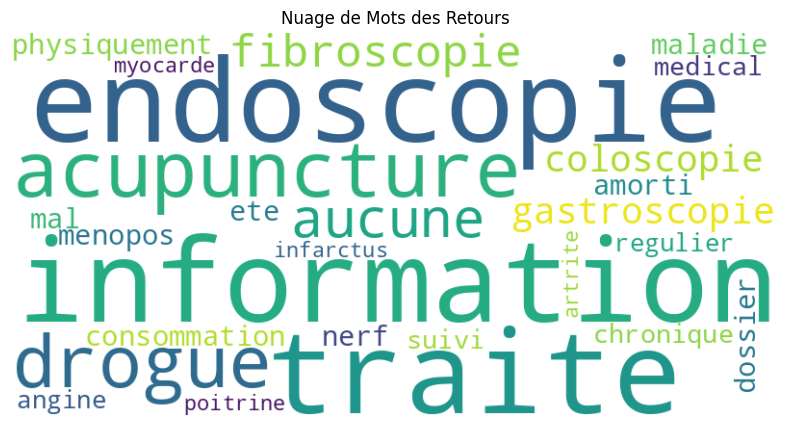

In [13]:
# Generate a word cloud from the cleaned feedback text
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df_Volontaire['cleaned_feedback']))

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Nuage de Mots des Retours')
plt.show()

<ipython-input-14-325fb223121e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


Index(['', 'aucune information',
       'endoscopie fibroscopie gastroscopie coloscopie', 'physiquement amorti',
       'traite acupuncture', 'mal nerf', 'information dossier',
       'consommation drogue', 'menopos', 'ete traite acupuncture',
       'endoscopie', 'drogues', 'maladie chronique suivi medical regulier',
       'angine poitrine artrite infarctus myocarde'],
      dtype='object', name='cleaned_feedback')


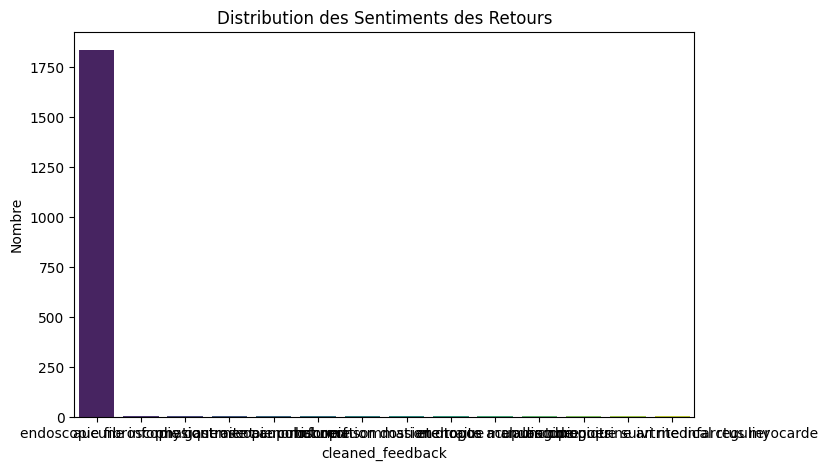

In [14]:
# Count sentiment occurrences
sentiment_counts = df_Volontaire['cleaned_feedback'].value_counts()

# Set up the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution des Sentiments des Retours')
plt.xlabel('cleaned_feedback')
plt.ylabel('Nombre')
#plt.show()
print ( sentiment_counts.index)

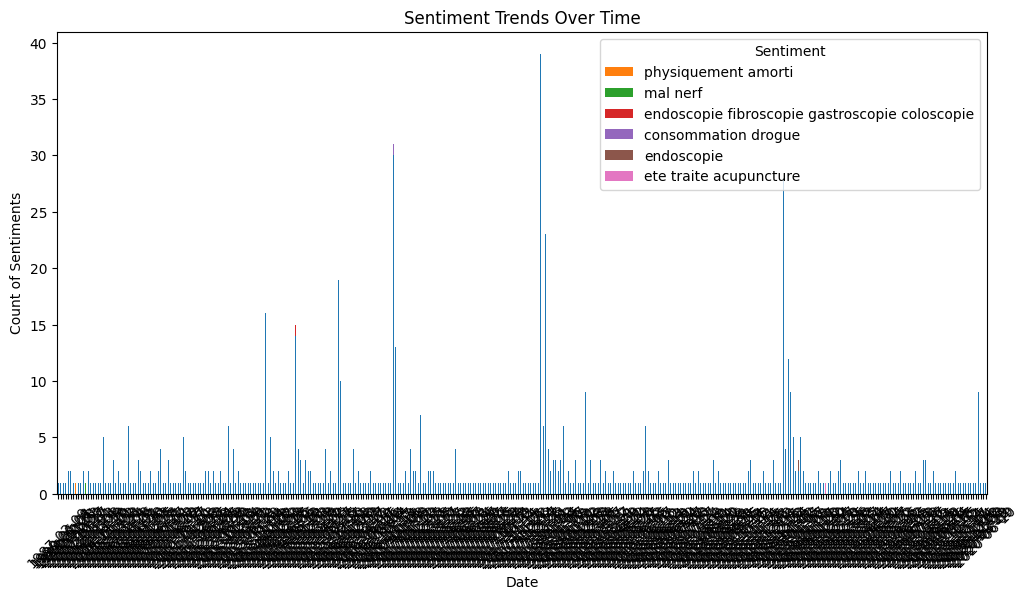

In [15]:
def parse_date(date_str):

  try:
    return pd.to_datetime(date_str, format='%d/%m/%Y %H:%M', errors='raise')  # First try day-first format
  except ValueError:
    try:
      return pd.to_datetime(date_str, format='%m/%d/%Y %H:%M', errors='raise')  # If that fails, try month-first format
    except ValueError:
      return pd.NaT  # Return NaT for unparsable dates

# Apply the custom function to the date column
df_Volontaire['date'] = df_Volontaire['Si_oui_preciser_la_date_du_dernier_don._'].apply(parse_date)

# Extract date for grouping
df_Volontaire['date'] = df_Volontaire['date'].dt.date
# Group by date and count sentiments
sentiment_trends = df_Volontaire.groupby(['date', 'cleaned_feedback']).size().unstack(fill_value=0)
# Plot sentiment trends over time
sentiment_trends.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Sentiment Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Count of Sentiments')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()

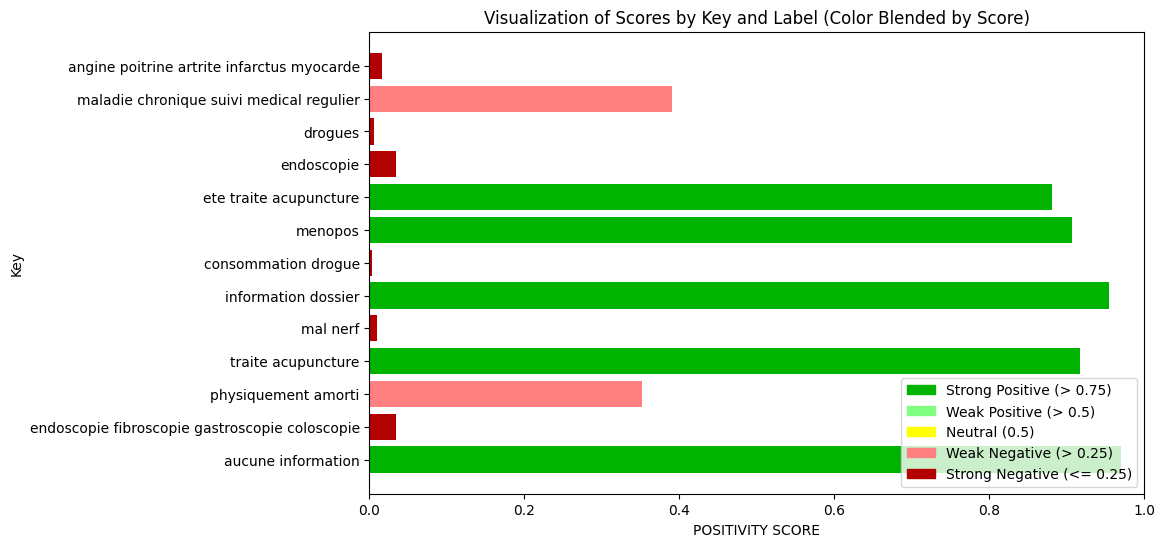

In [16]:
k = df_Volontaire['cleaned_feedback'].value_counts().index
sentiment_results = {}
for i in k:
  if i.replace (' ' , '') != '' :
    result = classifier(i)[0]
    if result['label'] == 'NEGATIVE' :
      result['score'] = 1 - result['score']
    sentiment_results[i] = result




keys = list(sentiment_results.keys())
scores = [item['score'] for item in sentiment_results.values()]
labels = [item['label'] for item in sentiment_results.values()]

def get_color(score):
    if score > 0.75:  # Strong Positive
        return (0, 0.7, 0)
    elif score > 0.5:
        return (0.5, 1, 0.5)
    elif score == 0.5:  # Neutral
        return (1, 1, 0)
    elif score > 0.25:  # Weak Negative
        return (1, 0.5, 0.5)
    else:
        return (0.7, 0, 0)

colors = [get_color(score) for score in scores]



fig, ax = plt.subplots(figsize=(10, 6))
bars = plt.barh(keys, scores, color=colors)
plt.xlabel('POSITIVITY SCORE')
plt.ylabel('Key')
plt.title('Visualization of Scores by Key and Label (Color Blended by Score)')
plt.xlim(0, 1)  # Set x-axis limits to 0-1 for better readability


legend_elements = [
    mpatch.Patch(color=(0, 0.7, 0), label='Strong Positive (> 0.75)'),
    mpatch.Patch(color=(0.5, 1, 0.5), label='Weak Positive (> 0.5)'),
    mpatch.Patch(color=(1, 1, 0), label='Neutral (0.5)'),
    mpatch.Patch(color=(1, 0.5, 0.5), label='Weak Negative (> 0.25)'),
    mpatch.Patch(color=(0.7, 0, 0), label='Strong Negative (<= 0.25)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.show()

In [18]:
import pandas as pd
from textblob import TextBlob

# Define a function to classify sentiment
def classify_sentiment(feedback):
    analysis = TextBlob(feedback)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the function to create sentiment labels
df_Volontaire['sentiment_label'] = df_Volontaire['cleaned_feedback'].apply(classify_sentiment)

# Encode sentiment labels as numerical values
df_Volontaire['sentiment_numeric'] = df_Volontaire['sentiment_label'].map({'Positive': 1, 'Negative': -1, 'Neutral': 0})

# Features and target variable
X = df_Volontaire['cleaned_feedback']
y = df_Volontaire['sentiment_numeric']

In [19]:
df_Volontaire['cleaned_feedback'].value_counts().index.names

FrozenList(['cleaned_feedback'])

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the text data
vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [21]:
result = classifier("This is dull")
print(result)

[{'label': 'NEGATIVE', 'score': 0.9998149275779724}]


In [22]:
(keys , scores , labels)

(['aucune information',
  'endoscopie fibroscopie gastroscopie coloscopie',
  'physiquement amorti',
  'traite acupuncture',
  'mal nerf',
  'information dossier',
  'consommation drogue',
  'menopos',
  'ete traite acupuncture',
  'endoscopie',
  'drogues',
  'maladie chronique suivi medical regulier',
  'angine poitrine artrite infarctus myocarde'],
 [0.9698030352592468,
  0.03467375040054321,
  0.35233789682388306,
  0.9164717793464661,
  0.009492993354797363,
  0.9538931846618652,
  0.003982365131378174,
  0.9062902331352234,
  0.8809215426445007,
  0.03384745121002197,
  0.0060007572174072266,
  0.39008569717407227,
  0.01567816734313965],
 ['POSITIVE',
  'NEGATIVE',
  'NEGATIVE',
  'POSITIVE',
  'NEGATIVE',
  'POSITIVE',
  'NEGATIVE',
  'POSITIVE',
  'POSITIVE',
  'NEGATIVE',
  'NEGATIVE',
  'NEGATIVE',
  'NEGATIVE'])

In [24]:
def test_sample_feedback(feedback):
    """Test a sample feedback and return its sentiment prediction."""
    cleaned = preprocess_text(feedback)
    vectorized = vectorizer.transform([cleaned])  # Vectorize the cleaned feedback
    prediction = models['Random Forest'].predict(vectorized)  # Use the best model
    sentiment = 'Positive' if prediction == 1 else 'Negative' if prediction == -1 else 'Neutral'
    return sentiment

# Example usage
sample_feedback = "C'était une expérience incroyable!"
print(f'Sample Feedback: "{sample_feedback}" => Sentiment: {test_sample_feedback(sample_feedback)}')

Sample Feedback: "C'était une expérience incroyable!" => Sentiment: Neutral


In [25]:
# Save the best model (RandomForest in this case)
joblib.dump(models['Random Forest'], 'sentiment_analysis_model.pkl')

# Save the vectorizer for future use
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Save the DataFrame with sentiment analysis results for future reference
df.to_pickle('processed_volontaire_dataset.pkl')

In [26]:
!pip install --upgrade pigar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.7/29.7 MB 20.4 MB/s eta 0:00:00


In [27]:
!pigar

Usage: pigar [OPTIONS] COMMAND [ARGS]...

  A tool to generate requirements.txt for your Python project, and more than that.

  NOTE that pigar is not a package/dependency management tool.

Options:
  --version                       Show the version and exit.
  -l, --log-level [ERROR|WARNING|INFO|DEBUG]
                                  Show given level log messages. The DEBUG level will print log
                                  messages from third party packages.  [default: WARNING]
  -h, --help                      Show this message and exit.

Commands:
  check     Check latest versions for packages/distributions from requirements.txt.
  generate  Generate requirements.txt for the given Python project.
  gohome    Go to the project home page to report a BUG or find more information.
  indexdb   Index database related operations.
  search    Search packages/distributions by the top level import/module names


In [28]:
!pigar generate


Requirements file has been overwritten, no difference.
Requirements has been written to /content/requirements.txt.


In [32]:
import pickle
import pickle

# Specify the path to save the .pkl file
desktop_path = r'C:\Users\Larry\Desktop\sentiments\sentiments_model.pkl'

# Save the model to a .pkl file
with open(desktop_path, 'wb') as file:
    pickle.dump(models, file)

print("Model saved as .pkl file on the desktop.")
with open(desktop_path, 'wb') as file:
    pickle.dump(models, file)

Model saved as .pkl file on the desktop.
Model saved as .pkl file on the desktop.
